In [6]:
############################## Chargement des données et fusions ###############################

# 1. Importer les bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 2. Charger les fichiers
input_path = "../inputs/"  # <-- adapte ton chemin si besoin
df_csp = pd.read_excel(input_path + "COM2021_pourcentage_csp..xlsx", skiprows=3)
df_communes = pd.read_csv(input_path + "comp_communale_csv.csv", encoding="ISO-8859-1", sep=",")
df_pop = pd.read_excel(input_path + "base-pop-historiques-2021.xlsx")

# 3. Nettoyer les colonnes
df_csp = df_csp.rename(columns={
    "LIBELLE": "NomCommune",
    "Unnamed: 48": "PopulationActive",
    "Unnamed: 49": "TotalCadres",
    "Unnamed: 50": "TotalOuvriers",
    "Unnamed: 53": "TotalProfIntermédiaires",
    "Unnamed: 54": "TotalEmployés"
})

df_communes.columns = df_communes.columns.str.replace("Ã©", "é").str.replace("Ã", "à")
df_communes = df_communes.rename(columns={
    "Code géographique": "CODGEO",
    "Libellé géographique": "NomCommune",
    "Aire d'attraction des villes 2020": "AAV2020",
    "Libellé aire d'attraction des villes 2020": "LIBAAV2020"
})

df_pop = df_pop.rename(columns={
    "CODGEO": "CODGEO",
    "LIBGEO": "NomCommune",
    "PMUN2021": "PopulationTotale"
})
df_pop = df_pop[["CODGEO", "NomCommune", "PopulationTotale"]]

# 4. Fusionner les bases
df_merge = pd.merge(df_communes, df_pop, on=["CODGEO", "NomCommune"], how="inner")
df_fusion = pd.merge(df_csp, df_merge, on="NomCommune", how="inner")

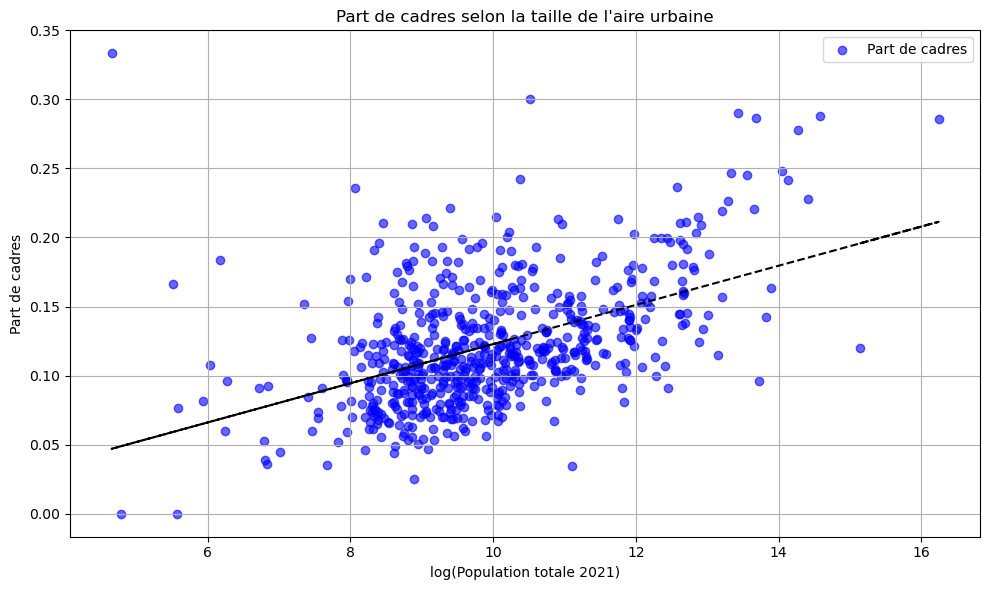

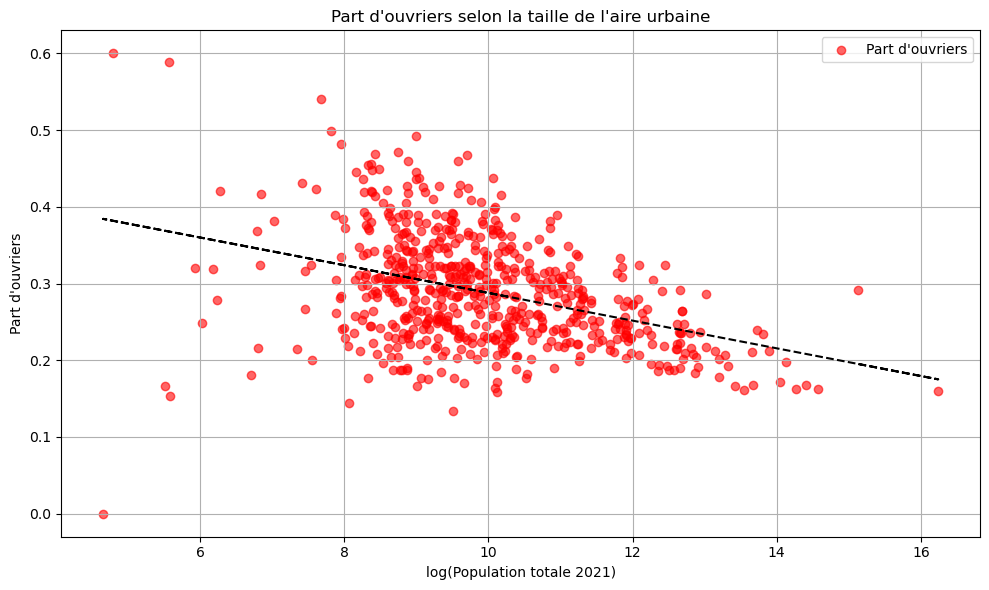

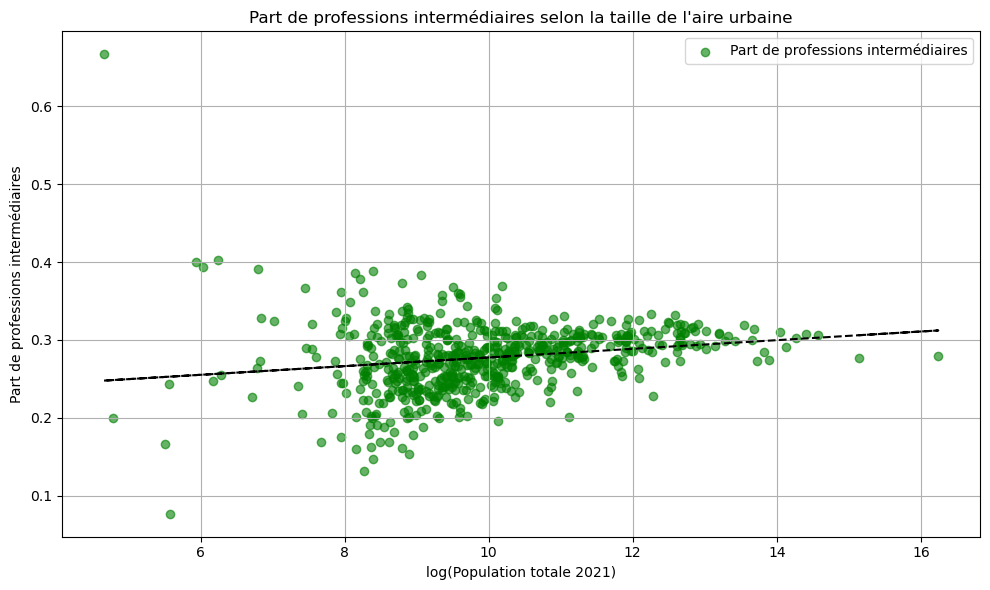

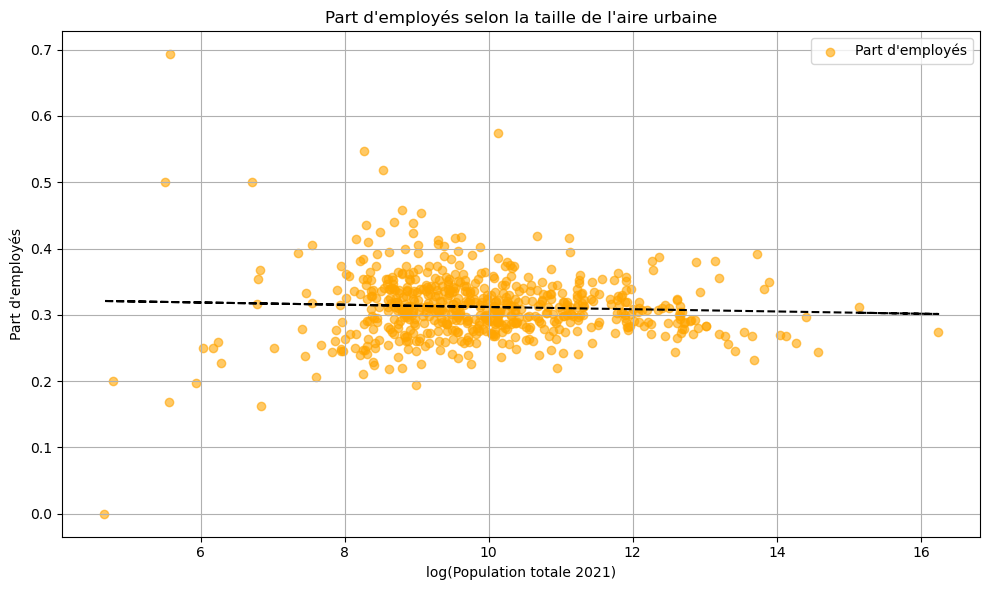

In [4]:
#################################### Analyse de la composition sociale ######################################

# 5. Agréger par aire urbaine
df_agg = df_fusion.groupby(["AAV2020", "LIBAAV2020"]).agg({
    "TotalCadres": "sum",
    "TotalOuvriers": "sum",
    "TotalProfIntermédiaires": "sum",
    "TotalEmployés": "sum",
    "PopulationTotale": "sum"
}).reset_index()

# 6. Calcul des parts
total_csp = df_agg[["TotalCadres", "TotalOuvriers", "TotalProfIntermédiaires", "TotalEmployés"]].sum(axis=1)
df_agg["PartCadres"] = df_agg["TotalCadres"] / total_csp
df_agg["PartOuvriers"] = df_agg["TotalOuvriers"] / total_csp
df_agg["PartProfIntermédiaires"] = df_agg["TotalProfIntermédiaires"] / total_csp
df_agg["PartEmployés"] = df_agg["TotalEmployés"] / total_csp

# 7. Calcul log population
df_agg["logPopulation"] = np.log(df_agg["PopulationTotale"])

# 8. Tracer les parts
categories = {
    "PartCadres": "Part de cadres",
    "PartOuvriers": "Part d'ouvriers",
    "PartProfIntermédiaires": "Part de professions intermédiaires",
    "PartEmployés": "Part d'employés"
}

colors = {
    "PartCadres": "blue",
    "PartOuvriers": "red",
    "PartProfIntermédiaires": "green",
    "PartEmployés": "orange"
}

for col, title in categories.items():
    plt.figure(figsize=(10,6))
    plt.scatter(df_agg["logPopulation"], df_agg[col], alpha=0.6, color=colors[col], label=title)
    coef = np.polyfit(df_agg["logPopulation"], df_agg[col], 1)
    tendance = np.poly1d(coef)
    plt.plot(df_agg["logPopulation"], tendance(df_agg["logPopulation"]), linestyle='dashed', color="black")
    plt.xlabel("log(Population totale 2021)")
    plt.ylabel(title)
    plt.title(f"{title} selon la taille de l'aire urbaine")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

                            OLS Regression Results                            
Dep. Variable:           IndiceDuncan   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     23.48
Date:                Mon, 28 Apr 2025   Prob (F-statistic):           1.60e-06
Time:                        11:07:50   Log-Likelihood:                 432.37
No. Observations:                 630   AIC:                            -860.7
Df Residuals:                     628   BIC:                            -851.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0607      0.033      1.865

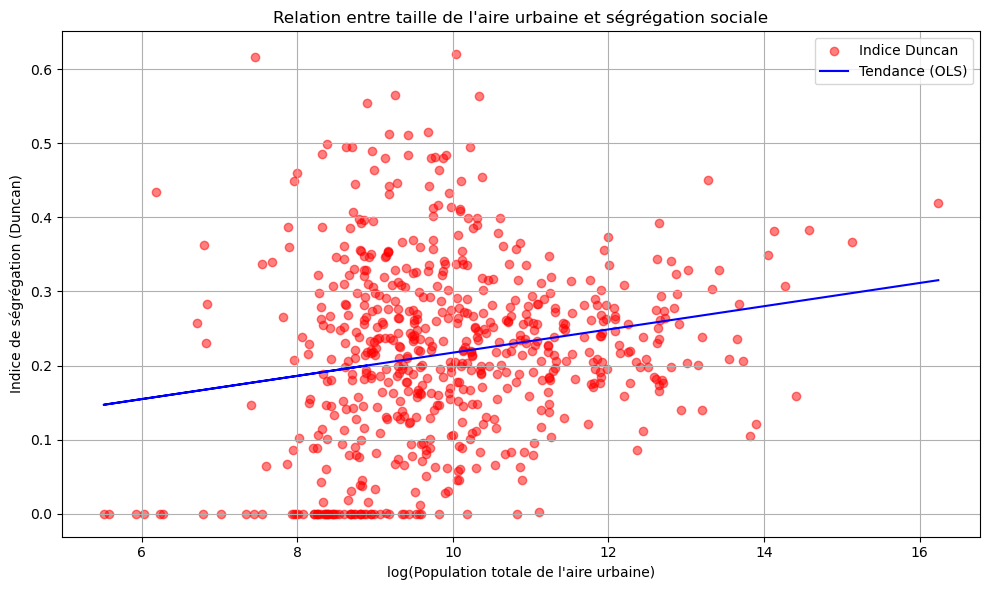

In [12]:
########################### Calcul de l'indice de Duncan et Duncan par CSP #################################

# 1. Calculer Duncan pour chaque aire urbaine
def calculer_duncan(df_aire):
    total_cadres = df_aire["TotalCadres"].sum()
    total_ouvriers = df_aire["TotalOuvriers"].sum()
    if total_cadres == 0 or total_ouvriers == 0:
        return None
    part_cadres = df_aire["TotalCadres"] / total_cadres
    part_ouvriers = df_aire["TotalOuvriers"] / total_ouvriers
    return 0.5 * np.abs(part_cadres - part_ouvriers).sum()

resultats = []
for code_aire in df_fusion["AAV2020"].dropna().unique():
    df_aire = df_fusion[df_fusion["AAV2020"] == code_aire]
    duncan = calculer_duncan(df_aire)
    pop_totale = df_aire["PopulationTotale"].sum()
    log_pop = np.log(pop_totale) if pop_totale > 0 else np.nan
    resultats.append({
        "AAV2020": code_aire,
        "IndiceDuncan": duncan,
        "PopulationTotale": pop_totale,
        "logPopulation": log_pop
    })

df_resultats = pd.DataFrame(resultats).dropna()

# 2. Régression Duncan ~ log(Population)
X = sm.add_constant(df_resultats["logPopulation"])
y = df_resultats["IndiceDuncan"]
model = sm.OLS(y, X).fit()

# 3. Afficher résumé de la régression
print(model.summary())


# 4. Tracer graphique
plt.figure(figsize=(10, 6))
plt.scatter(df_resultats["logPopulation"], df_resultats["IndiceDuncan"], color="red", alpha=0.5, label="Indice Duncan")
plt.plot(df_resultats["logPopulation"], model.predict(X), color="blue", label="Tendance (OLS)")
plt.xlabel("log(Population totale de l'aire urbaine)")
plt.ylabel("Indice de ségrégation (Duncan)")
plt.title("Relation entre taille de l'aire urbaine et ségrégation sociale")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:               Entropie   R-squared:                       0.273
Model:                            OLS   Adj. R-squared:                  0.272
Method:                 Least Squares   F-statistic:                     237.5
Date:                Mon, 28 Apr 2025   Prob (F-statistic):           1.04e-45
Time:                        11:24:19   Log-Likelihood:                 1009.8
No. Observations:                 633   AIC:                            -2016.
Df Residuals:                     631   BIC:                            -2007.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.1151      0.013     87.332

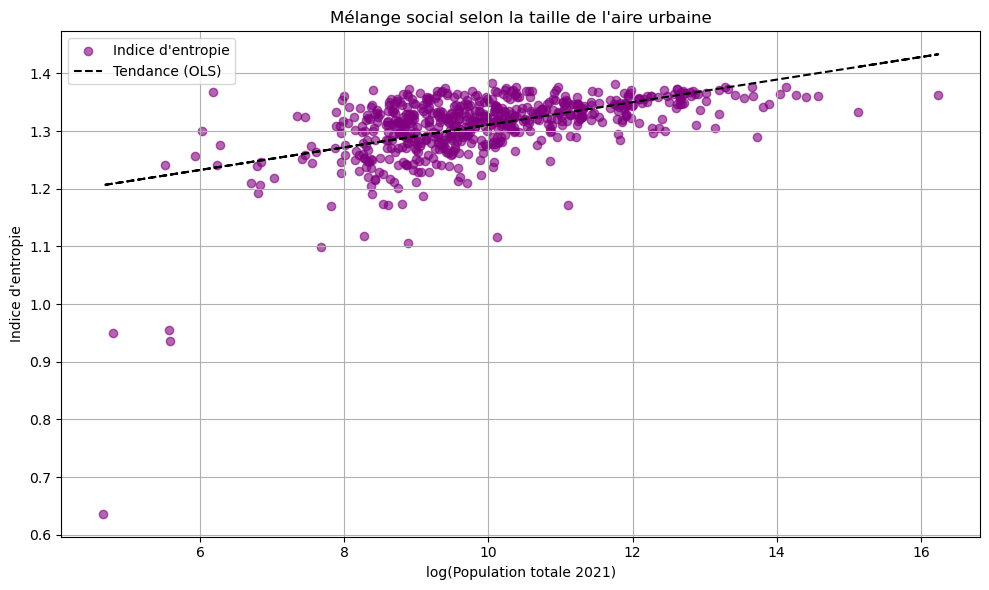

In [18]:
########## bonus pour aller plus loin ##########

# 1. Calculer l'indice d'entropie pour chaque aire urbaine
def calculer_entropie(row):
    groupes = ["PartCadres", "PartProfIntermédiaires", "PartEmployés", "PartOuvriers"]
    entropie = 0
    for g in groupes:
        p = row[g]
        if p > 0:
            entropie += p * np.log(p)
    return -entropie

df_agg["Entropie"] = df_agg.apply(calculer_entropie, axis=1)

# 2. Régression Entropie ~ log(Population)
import statsmodels.api as sm

X_entropie = sm.add_constant(df_agg["logPopulation"])
y_entropie = df_agg["Entropie"]
model_entropie = sm.OLS(y_entropie, X_entropie).fit()

# 3. Résumé de la régression
print(model_entropie.summary())

# 4. Scatter plot de l'entropie avec tendance
plt.figure(figsize=(10,6))
plt.scatter(df_agg["logPopulation"], df_agg["Entropie"], color='purple', alpha=0.6, label="Indice d'entropie")
plt.plot(df_agg["logPopulation"], model_entropie.predict(X_entropie), color='black', linestyle='dashed', label="Tendance (OLS)")
plt.xlabel("log(Population totale 2021)")
plt.ylabel("Indice d'entropie")
plt.title("Mélange social selon la taille de l'aire urbaine")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()